In [44]:
# Usage guide:

# This document is not kept on record. If the calcualtions are to be kept,
# copy the whole notebook and put it in "quick_calculations" or appropriate
# folders.

In [45]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
import scienceplots

plt.style.use("science")

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

In [46]:
Bmin_gauss = 10
Bmax_gauss = 30
N_B = 501
c_lines = "blue"
c_marker = "black"

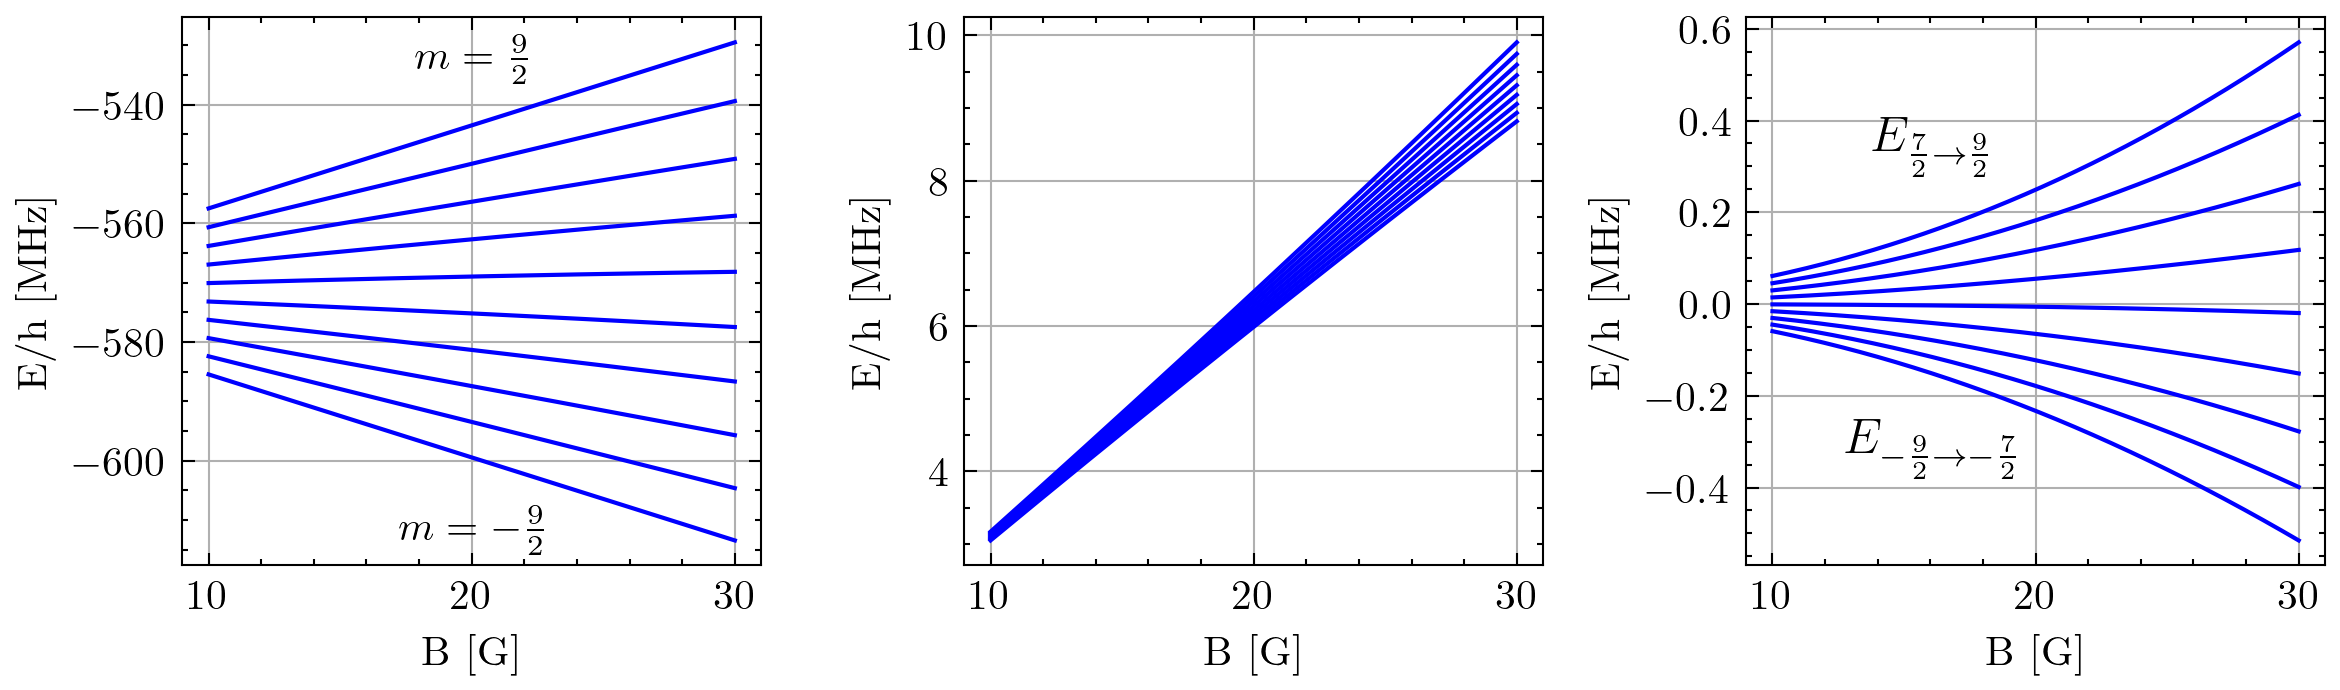

In [56]:
fig, axes = plt.subplots(1, 3, figsize = (8, 2.5), dpi = 300)
K40 = E9a.K40_4_2S1o2_F9o2


B_gauss = np.linspace(Bmin_gauss, Bmax_gauss, N_B)
B_Tesla = B_gauss / 1e4
E_mF = np.zeros([int(2 * K40.F + 1), len(B_Tesla)])
for i, mFnow in enumerate(np.arange(- K40.F, K40.F + 1, 1)):
    E_Breit = K40.GetBreitRabi(mFnow, B_Tesla)
    E_mF[i, :] = E_Breit / E9c.hnobar / 1e6
DeltaE_mF = E_mF[1:,:] - E_mF[:-1,:]
DeltaE_mF_offset = DeltaE_mF - np.tile(np.mean(DeltaE_mF, axis = 0), (int(2 * K40.F), 1))

for i in range(int(2 * K40.F)):
    axes[0].plot(B_gauss, E_mF[i, :], color = c_lines)
    axes[1].plot(B_gauss, DeltaE_mF[i, :], color = c_lines)
    axes[2].plot(B_gauss, DeltaE_mF_offset[i, :], color = c_lines)
axes[0].plot(B_gauss, E_mF[-1, :], color = c_lines)

i_text_E = 250
axes[0].text(B_gauss[i_text_E], E_mF[0, i_text_E] - 8, r'$m = -\frac{9}{2}$', fontsize = 10, ha = "center", va = "top")
axes[0].text(B_gauss[i_text_E], E_mF[-1, i_text_E] + 7, r'$m = \frac{9}{2}$', fontsize = 10, ha = "center", va = "bottom")
i_text_DE = 150
axes[2].text(B_gauss[i_text_DE], DeltaE_mF_offset[0, i_text_DE] - 0.1, r'$E_{-\frac{9}{2} \rightarrow -\frac{7}{2}}$', fontsize = 12, ha = "center", va = "top")
axes[2].text(B_gauss[i_text_DE], DeltaE_mF_offset[-1, i_text_DE] + 0.12, r'$E_{\frac{7}{2} \rightarrow \frac{9}{2}}$', fontsize = 12, ha = "center", va = "bottom")

for ax in axes:
    ax.grid("on")
    ax.set_xlabel("B [G]")
    ax.set_ylabel("E/h [MHz]")

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
file_full_path = Path(thesis_fig_path, "K40_Breit_Rabi.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')